C:\Users\Fmirw\AppData\Local\Temp\ipykernel_9820\96543989.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


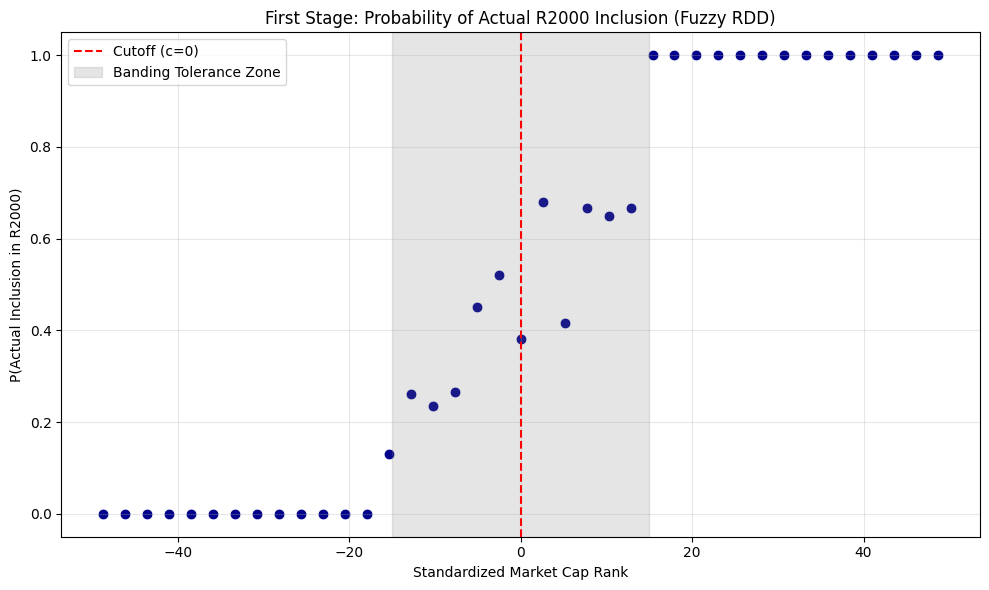

--- FINANCIAL ENHANCEMENT: FUZZY RDD ESTIMATION ---
Using Z (Rank >= 0) as an Instrument for D (Actual Inclusion)

[Second Stage LATE] Outcome: Cumulative Abnormal Returns (CAR)
Estimated Tau_RD:  -1.4648
Robust Std. Error: 1.2865
P-value:           0.2549

[Second Stage LATE] Outcome: Abnormal Trading Volume
Estimated Tau_RD:  -27.4529
Robust Std. Error: 28.9576
P-value:           0.3431

--- Generating RD Plot for Abnormal Volume ---


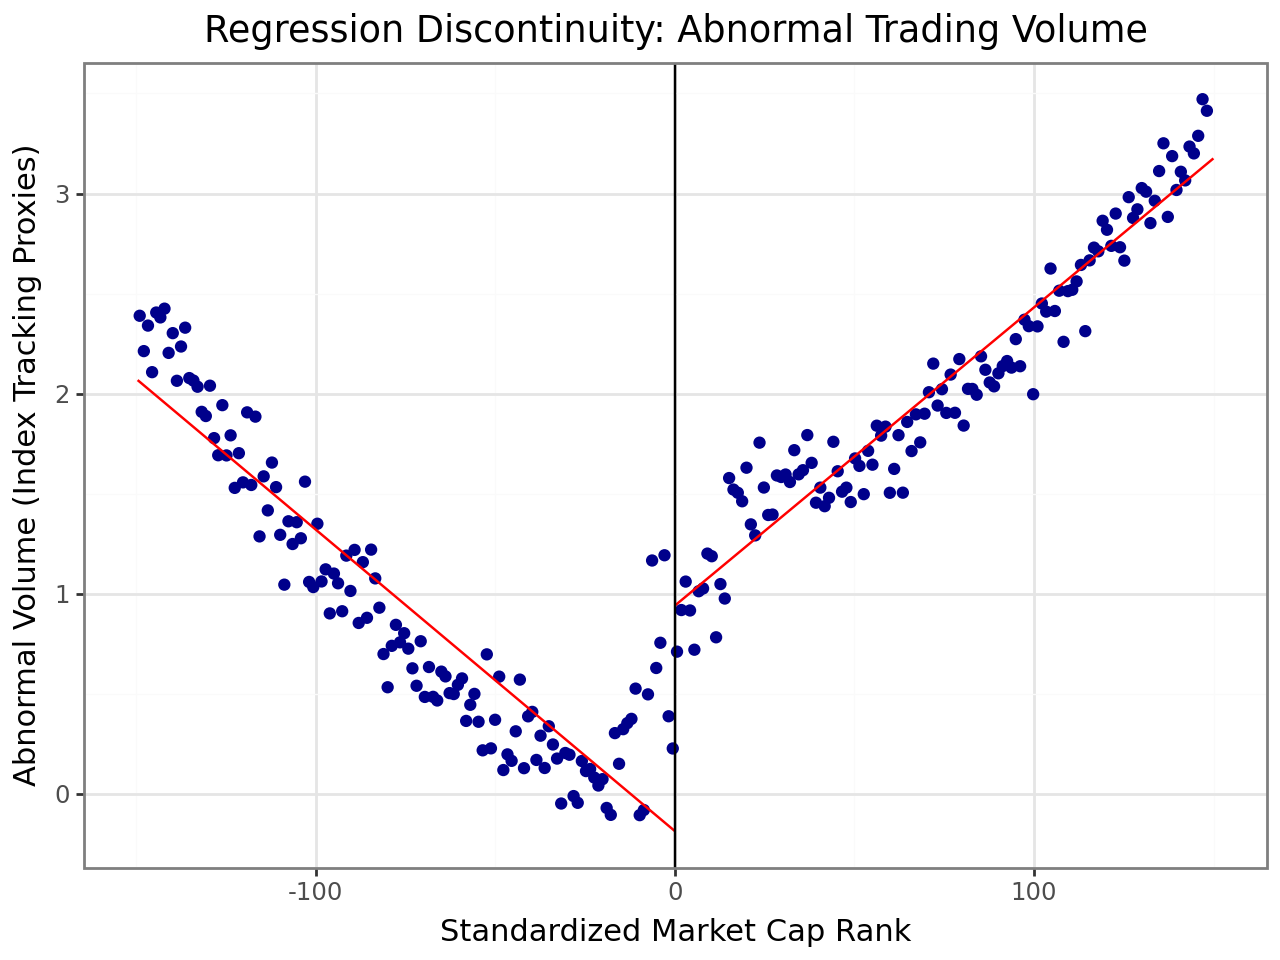

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# Note: You may need to install rdrobust for Python: pip install rdrobust
try:
    from rdrobust import rdrobust, rdplot
except ImportError:
    print("Warning: 'rdrobust' for Python not found. Run `pip install rdrobust`.")

np.random.seed(42)

# ==============================================================================
# 1. Enhanced Data Generation Process (DGP) with Financial Logic
# ==============================================================================
N = 2500
cutoff_c = 0 

# Running Variable: Standardized Market Cap Rank (centered at 0)
X = np.random.uniform(-150, 150, N)
X.sort()

# Lagged Index Membership (simulated based on historical momentum)
# 1 = Was in R2000 last year, 0 = Was in R1000 last year
lagged_prob = 1 / (1 + np.exp(-0.05 * X)) # Higher rank (positive X) more likely to have been in R2000
lagged_index = np.random.binomial(1, lagged_prob)

# Instrumental Variable (Z): The theoretical assignment rule (Sharp cutoff)
Z = np.where(X >= cutoff_c, 1, 0)

# ------------------------------------------------------------------------------
# FINANCIAL ENHANCEMENT A: Banding Rule (Fuzzy Assignment)
# A stock at rank +5 (Z=1, theoretical R2000) might stay in R1000 if it was 
# in R1000 last year and didn't cross the tolerance band.
# ------------------------------------------------------------------------------
band_tolerance = 15  # Ranks within +/- 15 of cutoff are subject to banding inertia

D_actual = np.zeros(N)
for i in range(N):
    if abs(X[i]) <= band_tolerance:
        # Inside the band: Strong inertia, defaults to lagged index
        D_actual[i] = lagged_index[i]
    else:
        # Outside the band: Theoretical assignment applies
        D_actual[i] = Z[i]

# ------------------------------------------------------------------------------
# FINANCIAL ENHANCEMENT B: Dual Outcomes (CAR and Volume)
# - f_X_car: Smooth fundamental size effect on returns
# - f_X_vol: Smooth fundamental size effect on trading volume
# ------------------------------------------------------------------------------
tau_RD_car = 0.035  # 3.5% causal jump in CAR 
tau_RD_vol = 1.50   # 150% causal jump in Abnormal Volume (mechanical buying)

f_X_car = 0.001 * X - 0.00005 * X**2
f_X_vol = -0.002 * X + 0.0001 * X**2  # Smaller firms natively trade slightly differently

# Heteroskedastic noise (smaller firms have higher idiosyncratic volatility)
noise_car = np.random.normal(0, 0.03 + 0.01 * (X > 0).astype(int), N)
noise_vol = np.random.normal(0, 0.4, N)

# True Potential Outcomes based on ACTUAL inclusion (Fuzzy RD logic)
Y_CAR = f_X_car + tau_RD_car * D_actual + noise_car
Y_VOL = f_X_vol + tau_RD_vol * D_actual + noise_vol

# Create DataFrame
df = pd.DataFrame({
    'Rank': X,
    'Theory_Assign_Z': Z,
    'Actual_Assign_D': D_actual,
    'Lagged_Index': lagged_index,
    'CAR': Y_CAR,
    'Abnormal_Volume': Y_VOL
})

# ==============================================================================
# 2. First Stage: Visualizing the Fuzzy Assignment (Banding Rule)
# ==============================================================================
plt.figure(figsize=(10, 6))
# Bin the data to calculate empirical probability of treatment
bins = pd.cut(df['Rank'], bins=np.linspace(-50, 50, 40))
binned_prob = df.groupby(bins)['Actual_Assign_D'].mean().reset_index()
binned_prob['Rank_Mid'] = binned_prob['Rank'].apply(lambda x: x.mid)

sns.scatterplot(x='Rank_Mid', y='Actual_Assign_D', data=binned_prob, color='darkblue', s=60)
plt.axvline(x=0, color='red', linestyle='--', label='Cutoff (c=0)')
plt.axvspan(-band_tolerance, band_tolerance, color='gray', alpha=0.2, label='Banding Tolerance Zone')
plt.title('First Stage: Probability of Actual R2000 Inclusion (Fuzzy RDD)')
plt.xlabel('Standardized Market Cap Rank')
plt.ylabel('P(Actual Inclusion in R2000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. Fuzzy RDD Estimation (Two-Stage Least Squares/IV approach)
# ==============================================================================
print("--- FINANCIAL ENHANCEMENT: FUZZY RDD ESTIMATION ---")
print("Using Z (Rank >= 0) as an Instrument for D (Actual Inclusion)")

# For demonstration, we manually compute Local Linear 2SLS within a specific bandwidth
# In practice, rdrobust handles fuzzy=D_actual directly, but statsmodels IV2SLS makes 
# the financial econometrics strictly explicit.
optimal_bw = 30 
df_local = df[(df['Rank'] >= -optimal_bw) & (df['Rank'] <= optimal_bw)].copy()

# Add interaction term for local linear regression allowing different slopes
df_local['Rank_x_Z'] = df_local['Rank'] * df_local['Theory_Assign_Z']

# First Stage: Regress Actual D on Instrument Z and running variables
exog_stage1 = sm.add_constant(df_local[['Theory_Assign_Z', 'Rank', 'Rank_x_Z']])
stage1_model = sm.OLS(df_local['Actual_Assign_D'], exog_stage1).fit()
df_local['D_hat'] = stage1_model.predict(exog_stage1)

# Second Stage (CAR): Regress CAR on instrumented D_hat
exog_stage2 = sm.add_constant(df_local[['D_hat', 'Rank', 'Rank_x_Z']])
stage2_car = sm.OLS(df_local['CAR'], exog_stage2).fit(cov_type='HC1') # Robust SEs

# Second Stage (Volume): Regress Volume on instrumented D_hat
stage2_vol = sm.OLS(df_local['Abnormal_Volume'], exog_stage2).fit(cov_type='HC1')

print("\n[Second Stage LATE] Outcome: Cumulative Abnormal Returns (CAR)")
print(f"Estimated Tau_RD:  {stage2_car.params['D_hat']:.4f}")
print(f"Robust Std. Error: {stage2_car.bse['D_hat']:.4f}")
print(f"P-value:           {stage2_car.pvalues['D_hat']:.4f}")

print("\n[Second Stage LATE] Outcome: Abnormal Trading Volume")
print(f"Estimated Tau_RD:  {stage2_vol.params['D_hat']:.4f}")
print(f"Robust Std. Error: {stage2_vol.bse['D_hat']:.4f}")
print(f"P-value:           {stage2_vol.pvalues['D_hat']:.4f}")

# ==============================================================================
# 4. RDD Visualization using rdplot (Python equivalent)
# ==============================================================================
# Visualizing the massive structural break in Volume
print("\n--- Generating RD Plot for Abnormal Volume ---")
try:
    # We plot the Intention-to-Treat (ITT) effect directly against the running variable
    rdp_vol = rdplot(y=df['Abnormal_Volume'], x=df['Rank'], c=cutoff_c, p=1, 
                     title="Regression Discontinuity: Abnormal Trading Volume",
                     x_label="Standardized Market Cap Rank",
                     y_label="Abnormal Volume (Index Tracking Proxies)")
except NameError:
    print("Skipping rdplot as rdrobust library is not imported.")